# Olist Silver Layer Transformation Notes

This notebook section documents the transformation logic applied when moving Olist data from the bronze layer to the silver layer. The focus is on preserving the original row-level structure of each table while applying controlled standardization, type normalization, and limited enrichment where justified by the EDA.

In [98]:
import polars as pl
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
BRONZE_DIR = PROJECT_ROOT / "data" / "bronze"

# Customers

This section examines the customer table in the bronze layer in order to confirm its row-level structure, assess identifier behavior, and determine which light standardization steps are appropriate for the silver transformation.

In [99]:
customers_df = pl.read_parquet(BRONZE_DIR / "customers.parquet")

customers_df.describe()

statistic,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,_source_file,_ingested_at
str,str,str,f64,str,str,str,str
"""count""","""99441""","""99441""",99441.0,"""99441""","""99441""","""99441""","""99441"""
"""null_count""","""0""","""0""",0.0,"""0""","""0""","""0""","""0"""
"""mean""",null,null,35137.474583,null,null,null,null
"""std""",null,null,29797.938996,null,null,null,null
"""min""","""00012a2ce6f8dcda20d059ce984917…","""0000366f3b9a7992bf8c76cfdf3221…",1003.0,"""abadia dos dourados""","""AC""","""olist_customers_dataset.csv""","""2026-04-08T17:30:23.970107+00:…"
"""25%""",null,null,11347.0,null,null,null,null
"""50%""",null,null,24416.0,null,null,null,null
"""75%""",null,null,58900.0,null,null,null,null
"""max""","""ffffe8b65bbe3087b653a978c870db…","""ffffd2657e2aad2907e67c3e9daecb…",99990.0,"""zortea""","""TO""","""olist_customers_dataset.csv""","""2026-04-08T17:30:23.970107+00:…"


In [156]:
customers_df.schema

Schema([('customer_id', String),
        ('customer_unique_id', String),
        ('customer_zip_code_prefix', Int64),
        ('customer_city', String),
        ('customer_state', String),
        ('_source_file', String),
        ('_ingested_at', String)])

In [146]:
customers_df.n_unique()

99441

In [102]:
customers_df['customer_id'].n_unique()

99441

`customer_unique_id` represents the person-level identifier, while `customer_id` is unique at the customer-record level linked to orders. This suggests that the same customer may appear in multiple records when making multiple purchases. For the silver layer, it is therefore reasonable to preserve both identifiers, avoid deduplicating by `customer_unique_id`, apply `TRIM()` to string identifier and metadata fields where appropriate, standardize `customer_city` with `LOWER(TRIM())`, standardize `customer_state` with `UPPER(TRIM())`, and cast `_ingested_at` to `TIMESTAMP` for consistent downstream processing.

# Geolocation

This section examines the geolocation reference table in the bronze layer in order to assess its granularity, identify duplicate rows, inspect textual noise in location fields, and evaluate whether the latitude and longitude values are geographically consistent with Brazil.

In [103]:
geolocation_df = pl.read_parquet(BRONZE_DIR / "geolocation.parquet")

geolocation_df.describe()


statistic,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,_source_file,_ingested_at
str,f64,f64,f64,str,str,str,str
"""count""",1.000163e6,1.000163e6,1.000163e6,"""1000163""","""1000163""","""1000163""","""1000163"""
"""null_count""",0.0,0.0,0.0,"""0""","""0""","""0""","""0"""
"""mean""",36574.166466,-21.176153,-46.390541,null,null,null,null
"""std""",30549.33571,5.715866,4.269748,null,null,null,null
"""min""",1001.0,-36.605374,-101.466766,"""* cidade""","""AC""","""olist_geolocation_dataset.csv""","""2026-04-08T17:30:24.219112+00:…"
"""25%""",11075.0,-23.603545,-48.573137,null,null,null,null
"""50%""",26530.0,-22.919377,-46.637879,null,null,null,null
"""75%""",63504.0,-19.979614,-43.767703,null,null,null,null
"""max""",99990.0,45.065933,121.105394,"""óleo""","""TO""","""olist_geolocation_dataset.csv""","""2026-04-08T17:30:24.219112+00:…"


In [155]:
geolocation_df.schema

Schema([('geolocation_zip_code_prefix', Int64),
        ('geolocation_lat', Float64),
        ('geolocation_lng', Float64),
        ('geolocation_city', String),
        ('geolocation_state', String),
        ('_source_file', String),
        ('_ingested_at', String),
        ('within_brazil_bbox', Boolean)])

Some values in `geolocation_city` contain leading or trailing special characters, which indicates minor textual noise in the raw location data. This supports light edge-cleaning in the silver layer through `TRIM()` and regular-expression-based normalization, while applying the same logic to `geolocation_state` as a cautious consistency step.

In [105]:
geolocation_df.n_unique()


738332

The `geolocation` table contains exact duplicate rows, which means that `SELECT DISTINCT` can be safely applied in the silver layer without collapsing genuinely different geographic observations. This reduces redundancy while preserving the reference-like nature of the dataset.

After confirming the presence of exact duplicate rows, the next step is to inspect the geographic plausibility of the coordinate fields, especially the most extreme latitude values, to determine whether the table contains observations that fall outside expected Brazilian bounds.

In [106]:
geolocation_df.sort("geolocation_lat", descending=True).head()

geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,_source_file,_ingested_at
i64,f64,f64,str,str,str,str
57319,45.065933,9.341528,"""pau d'arco""","""AL""","""olist_geolocation_dataset.csv""","""2026-04-08T17:30:24.219112+00:…"
28595,43.684961,-7.41108,"""portela""","""RJ""","""olist_geolocation_dataset.csv""","""2026-04-08T17:30:24.219112+00:…"
28155,42.439286,13.820214,"""santa maria""","""RJ""","""olist_geolocation_dataset.csv""","""2026-04-08T17:30:24.219112+00:…"
68447,42.428884,-6.873344,"""vila dos cabanos""","""PA""","""olist_geolocation_dataset.csv""","""2026-04-08T17:30:24.219112+00:…"
83252,42.184003,-8.723762,"""ilha dos valadares""","""PR""","""olist_geolocation_dataset.csv""","""2026-04-08T17:30:24.219112+00:…"


The geolocation data are mostly concentrated within Brazil, but a small number of coordinate outliers fall well outside expected Brazilian bounds. This suggests that the latitude and longitude fields contain a limited number of noisy or inconsistent records. One plausible explanation is that some city names are not globally unique and may also exist in other countries, which can lead to coordinates pointing to locations with matching city names outside Brazil. For the MVP, these coordinates should be preserved but treated with caution in downstream geographic analysis.

In [107]:
geolocation_df = geolocation_df.with_columns(
    (
        pl.col("geolocation_lat").is_between(-34.0, 5.5)
        & pl.col("geolocation_lng").is_between(-74.1, -34.5)
    ).alias("within_brazil_bbox")
)

geolocation_df.select(
    pl.len().alias("total_rows"),
    pl.col("within_brazil_bbox").sum().alias("inside_bbox"),
    (~pl.col("within_brazil_bbox")).sum().alias("outside_bbox"),
)


total_rows,inside_bbox,outside_bbox
u32,u32,u32
1000163,1000121,42


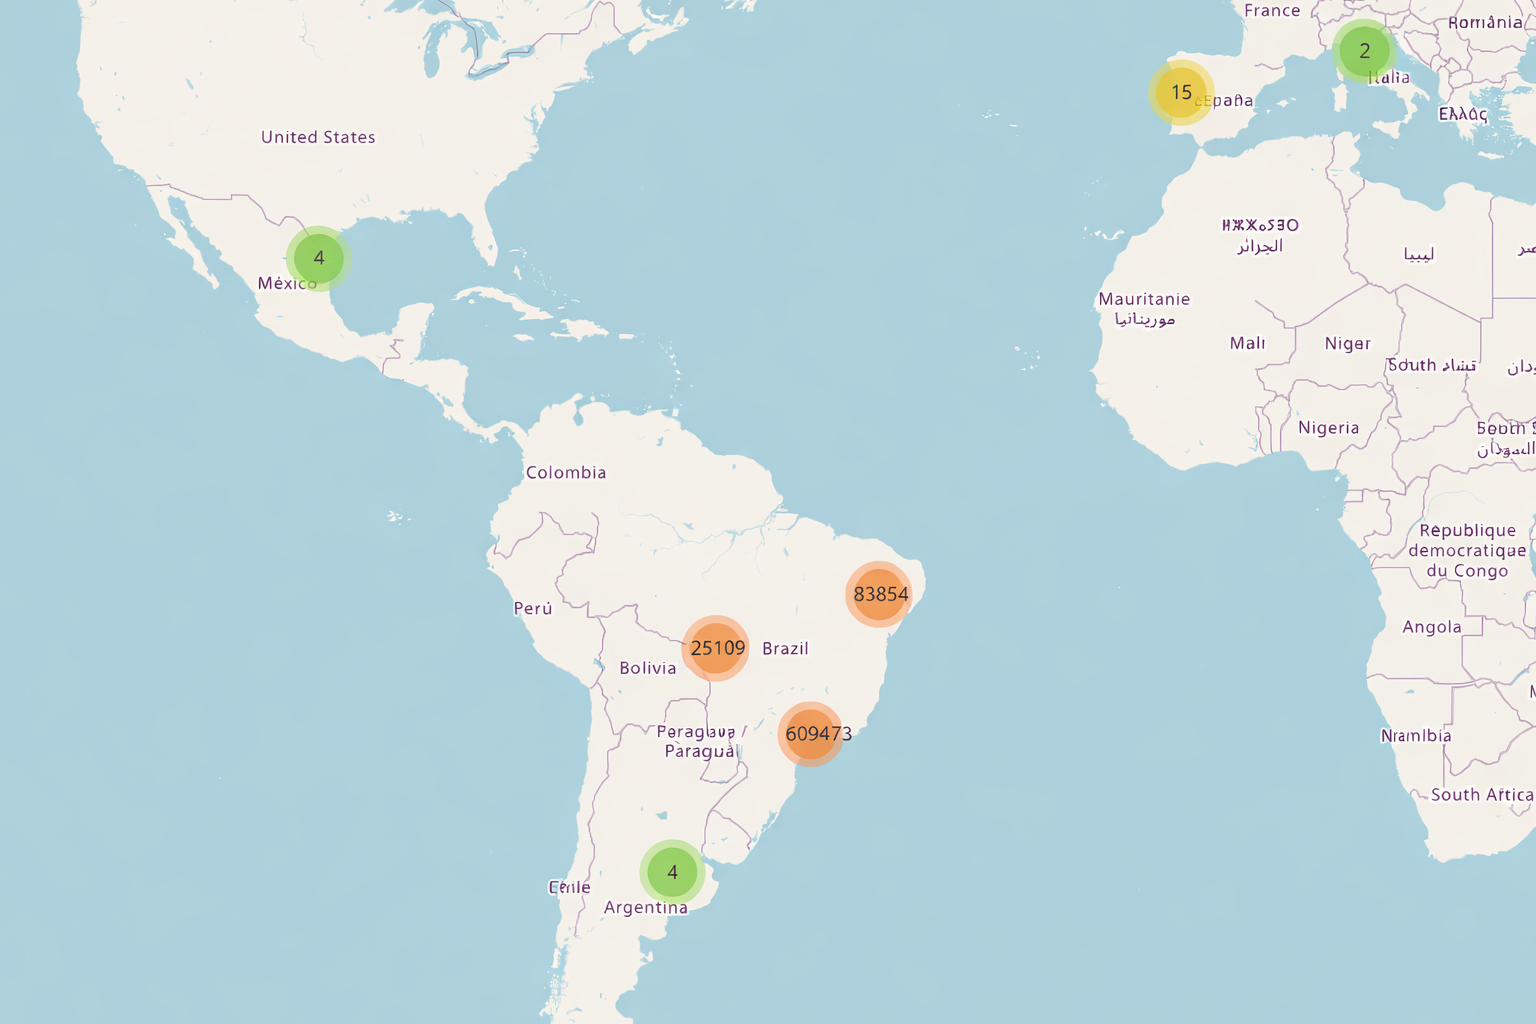

Note that this visualization is only approximate and intended for exploratory analysis. For precise geographic validation, the coordinates would require additional verification using more accurate geospatial methods and reference data.


Since `geolocation_zip_code_prefix` is not a unique row-level identifier, the `geolocation` table should be interpreted as a reference dataset rather than a simple dimension keyed only by ZIP code prefix. The same ZIP code prefix may correspond to multiple rows with different latitude and longitude values, so the silver transformation should preserve this reference structure while removing only exact duplicate rows. At this stage, the required transformations remain limited: keep `geolocation_lat` and `geolocation_lng` as numeric geographic fields, standardize `geolocation_city` through edge-cleaning and `LOWER()`, apply the same edge-cleaning logic and `UPPER()` to `geolocation_state`, preserve technical metadata fields where appropriate, and cast `_ingested_at` to `TIMESTAMP` for consistent technical lineage and downstream quality checks.

# Order Items

This section examines the `order_items` table in order to confirm its row-level granularity, inspect how repeated product entries behave within the same order, and determine whether the silver transformation should preserve the original order-line structure or introduce any aggregation.

In [108]:
order_items_df = pl.read_parquet(BRONZE_DIR / "order_items.parquet")

order_items_df.describe()


statistic,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,_source_file,_ingested_at
str,str,f64,str,str,str,f64,f64,str,str
"""count""","""112650""",112650.0,"""112650""","""112650""","""112650""",112650.0,112650.0,"""112650""","""112650"""
"""null_count""","""0""",0.0,"""0""","""0""","""0""",0.0,0.0,"""0""","""0"""
"""mean""",null,1.197834,null,null,null,120.653739,19.99032,null,null
"""std""",null,0.705124,null,null,null,183.633928,15.806405,null,null
"""min""","""00010242fe8c5a6d1ba2dd792cb162…",1.0,"""00066f42aeeb9f3007548bb9d3f33c…","""0015a82c2db000af6aaaf3ae2ecb05…","""2016-09-19 00:15:34""",0.85,0.0,"""olist_order_items_dataset.csv""","""2026-04-08T17:30:24.429336+00:…"
"""25%""",null,1.0,null,null,null,39.9,13.08,null,null
"""50%""",null,1.0,null,null,null,74.99,16.26,null,null
"""75%""",null,1.0,null,null,null,134.9,21.15,null,null
"""max""","""fffe41c64501cc87c801fd61db3f62…",21.0,"""fffe9eeff12fcbd74a2f2b007dde0c…","""ffff564a4f9085cd26170f47323937…","""2020-04-09 22:35:08""",6735.0,409.68,"""olist_order_items_dataset.csv""","""2026-04-08T17:30:24.429336+00:…"


In [154]:
order_items_df.schema

Schema([('order_id', String),
        ('order_item_id', Int64),
        ('product_id', String),
        ('seller_id', String),
        ('shipping_limit_date', String),
        ('price', Float64),
        ('freight_value', Float64),
        ('_source_file', String),
        ('_ingested_at', String)])

In [110]:
order_items_df.n_unique()

112650

Since `order_id` is expected to repeat in an order-line table, the key question is whether repeated rows represent accidental duplicates or valid separate line items. The following check focuses on orders with multiple rows in order to examine how `order_item_id`, `product_id`, and the remaining attributes behave within the same order.

In [111]:
order_items_df.filter(
    pl.len().over("order_id") > 1
).sort(["order_id", "order_item_id"])


order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,_source_file,_ingested_at
str,i64,str,str,str,f64,f64,str,str
"""0008288aa423d2a3f00fcb17cd7d87…",1,"""368c6c730842d78016ad823897a372…","""1f50f920176fa81dab994f90235231…","""2018-02-21 02:55:52""",49.9,13.37,"""olist_order_items_dataset.csv""","""2026-04-08T17:30:24.429336+00:…"
"""0008288aa423d2a3f00fcb17cd7d87…",2,"""368c6c730842d78016ad823897a372…","""1f50f920176fa81dab994f90235231…","""2018-02-21 02:55:52""",49.9,13.37,"""olist_order_items_dataset.csv""","""2026-04-08T17:30:24.429336+00:…"
"""00143d0f86d6fbd9f9b38ab440ac16…",1,"""e95ee6822b66ac6058e2e4aff65607…","""a17f621c590ea0fab3d5d883e1630e…","""2017-10-20 16:07:52""",21.33,15.1,"""olist_order_items_dataset.csv""","""2026-04-08T17:30:24.429336+00:…"
"""00143d0f86d6fbd9f9b38ab440ac16…",2,"""e95ee6822b66ac6058e2e4aff65607…","""a17f621c590ea0fab3d5d883e1630e…","""2017-10-20 16:07:52""",21.33,15.1,"""olist_order_items_dataset.csv""","""2026-04-08T17:30:24.429336+00:…"
"""00143d0f86d6fbd9f9b38ab440ac16…",3,"""e95ee6822b66ac6058e2e4aff65607…","""a17f621c590ea0fab3d5d883e1630e…","""2017-10-20 16:07:52""",21.33,15.1,"""olist_order_items_dataset.csv""","""2026-04-08T17:30:24.429336+00:…"
…,…,…,…,…,…,…,…,…
"""fff8287bbae429a99bb7e8c21d151c…",2,"""bee2e070c39f3dd2f6883a17a5f0da…","""4e922959ae960d389249c378d1c939…","""2018-03-27 12:29:22""",180.0,48.14,"""olist_order_items_dataset.csv""","""2026-04-08T17:30:24.429336+00:…"
"""fffb9224b6fc7c43ebb0904318b10b…",1,"""43423cdffde7fda63d0414ed38c11a…","""b1fc4f64df5a0e8b6913ab38803c57…","""2017-11-03 02:55:58""",55.0,34.19,"""olist_order_items_dataset.csv""","""2026-04-08T17:30:24.429336+00:…"
"""fffb9224b6fc7c43ebb0904318b10b…",2,"""43423cdffde7fda63d0414ed38c11a…","""b1fc4f64df5a0e8b6913ab38803c57…","""2017-11-03 02:55:58""",55.0,34.19,"""olist_order_items_dataset.csv""","""2026-04-08T17:30:24.429336+00:…"


The `order_items` table is stored at the order-line level, where each row represents a single order line within an order. Repeated `order_id`–`product_id` combinations often differ only by `order_item_id`, while fields such as `seller_id`, `price`, and `freight_value` remain identical, and `shipping_limit_date` remains consistent within these repeated line groups. This strongly suggests that multiple units of the same product were recorded as separate order lines, with `order_item_id` acting as the positional identifier within the order rather than indicating materially different items. Therefore, for the silver layer, it is reasonable to preserve the original row-level structure of the `order_items` table and avoid premature aggregation, while a derived `quantity` field can be introduced later in downstream analytical layers if needed. At this stage, the transformation should remain limited to light standardization of identifier and technical metadata fields, preservation of numeric fields in numeric format, and casting `shipping_limit_date` and `_ingested_at` to `TIMESTAMP`.

# Order Payments

This section examines the `order_payments` table in order to clarify its row-level granularity, assess whether multiple payment records per order are expected, and identify any rare anomalies that could affect the silver-layer transformation logic.

In [112]:
order_payments_df = pl.read_parquet(BRONZE_DIR / "order_payments.parquet")

order_payments_df.describe()


statistic,order_id,payment_sequential,payment_type,payment_installments,payment_value,_source_file,_ingested_at
str,str,f64,str,f64,f64,str,str
"""count""","""103886""",103886.0,"""103886""",103886.0,103886.0,"""103886""","""103886"""
"""null_count""","""0""",0.0,"""0""",0.0,0.0,"""0""","""0"""
"""mean""",null,1.092679,null,2.853349,154.10038,null,null
"""std""",null,0.706584,null,2.687051,217.494064,null,null
"""min""","""00010242fe8c5a6d1ba2dd792cb162…",1.0,"""boleto""",0.0,0.0,"""olist_order_payments_dataset.c…","""2026-04-08T17:30:24.521002+00:…"
"""25%""",null,1.0,null,1.0,56.79,null,null
"""50%""",null,1.0,null,1.0,100.0,null,null
"""75%""",null,1.0,null,4.0,171.84,null,null
"""max""","""fffe41c64501cc87c801fd61db3f62…",29.0,"""voucher""",24.0,13664.08,"""olist_order_payments_dataset.c…","""2026-04-08T17:30:24.521002+00:…"


In [153]:
order_payments_df.schema

Schema([('order_id', String),
        ('payment_sequential', Int64),
        ('payment_type', String),
        ('payment_installments', Int64),
        ('payment_value', Float64),
        ('_source_file', String),
        ('_ingested_at', String)])

In [114]:
order_payments_df.n_unique()

103886

In [115]:
order_payments_df["order_id"].n_unique()

99440

Since `order_id` is not expected to be unique in a payment-level table, the next step is to examine how `payment_type` and `payment_installments` behave across records in order to distinguish normal payment patterns from potential anomalies.

In [116]:
order_payments_df.group_by(["payment_type", "payment_installments"]).agg(
    pl.len().alias("cnt")
).sort(["payment_installments", "payment_type"])


payment_type,payment_installments,cnt
str,i64,u32
"""credit_card""",0,2
"""boleto""",1,19784
"""credit_card""",1,25455
"""debit_card""",1,1529
"""not_defined""",1,3
…,…,…
"""credit_card""",20,17
"""credit_card""",21,3
"""credit_card""",22,1


The grouped distribution suggests that most payment combinations follow expected business patterns, but a very small number of `credit_card` records with `payment_installments = 0` require closer inspection to determine whether they represent source-level inconsistencies or valid edge cases.

In [117]:
order_payments_df.filter(
    (pl.col("payment_type") == "credit_card") &
    (pl.col("payment_installments") == 0)
).select("order_id")


order_id
str
"""744bade1fcf9ff3f31d860ace076d4…"
"""1a57108394169c0b47d8f876acc9ba…"


In [118]:
anomalous_orders = order_payments_df.filter(
    (pl.col("payment_type") == "credit_card") &
    (pl.col("payment_installments") == 0)
).select("order_id")

order_payments_df.join(
    anomalous_orders,
    on="order_id",
    how="inner"
).sort(["order_id", "payment_sequential"])


order_id,payment_sequential,payment_type,payment_installments,payment_value,_source_file,_ingested_at
str,i64,str,i64,f64,str,str
"""1a57108394169c0b47d8f876acc9ba…",2,"""credit_card""",0,129.94,"""olist_order_payments_dataset.c…","""2026-04-08T17:30:24.521002+00:…"
"""744bade1fcf9ff3f31d860ace076d4…",2,"""credit_card""",0,58.69,"""olist_order_payments_dataset.c…","""2026-04-08T17:30:24.521002+00:…"


Two anomalous `credit_card` records with `payment_installments = 0` were identified. Moreover, when retrieving all payment records for the corresponding `order_id` values, only these same two rows were present in the dataset, even though both have `payment_sequential = 2`. This suggests an additional inconsistency in the payment sequencing, since the expected preceding payment record is absent. These cases should be preserved in the silver layer and documented as rare data quality anomalies.


In [119]:
order_payments_df.filter(
    pl.col("payment_value") == 0
).group_by(["payment_type", "payment_installments"]).agg(
    pl.len().alias("cnt")
).sort("cnt", descending=True)


payment_type,payment_installments,cnt
str,i64,u32
"""voucher""",1,6
"""not_defined""",1,3


A very small number of payment records have `payment_value = 0`, and these cases appear only for `voucher` and `not_defined` payment types. Since no zero-value records were observed for standard payment types such as `credit_card`, this pattern does not suggest a broad data quality issue. These rows are more likely to represent edge cases or platform-specific payment encoding and can be preserved in the silver layer.


Since `order_id` is not unique in `order_payments`, the table should be interpreted at the payment-record level rather than as a one-row-per-order structure. Multiple rows may legitimately exist for the same order, with `payment_sequential` indicating the position of each payment entry within that order. The observed distribution of `payment_type` and `payment_installments` is largely consistent with expected business behavior, while the few anomalous cases such as `credit_card` records with `payment_installments = 0` or zero-value payments should be preserved as rare source-level edge cases rather than corrected manually. Therefore, for the silver layer, it is reasonable to preserve all rows, avoid deduplication by `order_id`, standardize `payment_type` with `LOWER(TRIM())`, keep numeric payment fields in numeric format, and cast `_ingested_at` to `TIMESTAMP`.

# Order Reviews

This section examines the `order_reviews` table together with its translated counterpart in order to assess review-level granularity, compare the two sources, and determine how original and translated review texts should be handled in the silver layer.

In [ ]:
order_reviews_df = pl.read_parquet(BRONZE_DIR / "order_reviews.parquet")

order_reviews_df.describe()

statistic,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,_source_file,_ingested_at
str,str,str,f64,str,str,str,str,str,str
"""count""","""99224""","""99224""",99224.0,"""11568""","""40977""","""99224""","""99224""","""99224""","""99224"""
"""null_count""","""0""","""0""",0.0,"""87656""","""58247""","""0""","""0""","""0""","""0"""
"""mean""",null,null,4.086421,null,null,null,null,null,null
"""std""",null,null,1.347579,null,null,null,null,null,null
"""min""","""0001239bc1de2e33cb583967c2ca4c…","""00010242fe8c5a6d1ba2dd792cb162…",1.0,""" """,""" ""","""2016-10-02 00:00:00""","""2016-10-07 18:32:28""","""olist_order_reviews_dataset.cs…","""2026-04-08T17:30:24.626217+00:…"
"""25%""",null,null,4.0,null,null,null,null,null,null
"""50%""",null,null,5.0,null,null,null,null,null,null
"""75%""",null,null,5.0,null,null,null,null,null,null
"""max""","""fffefe7a48d22f7b32046421062219…","""fffe41c64501cc87c801fd61db3f62…",5.0,"""🔟 ""","""😡😡😡😡😡👎👎👎👎👎 Empresa sem compro…","""2018-08-31 00:00:00""","""2018-10-29 12:27:35""","""olist_order_reviews_dataset.cs…","""2026-04-08T17:30:24.626217+00:…"


In [152]:
order_reviews_df.schema

Schema([('review_id', String),
        ('order_id', String),
        ('review_score', Int64),
        ('review_comment_title', String),
        ('review_comment_message', String),
        ('review_creation_date', String),
        ('review_answer_timestamp', String),
        ('_source_file', String),
        ('_ingested_at', String)])

In [122]:
order_reviews_df.n_unique()

99224

After inspecting the original review table, the translated review dataset should be examined separately to determine whether it behaves as a strict one-to-one translation mapping or as a broader parallel version of the review data.

In [147]:
order_reviews_translated_df = pl.read_parquet(BRONZE_DIR / "order_reviews_translation.parquet")

order_reviews_translated_df.describe()

statistic,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,_source_file,_ingested_at
str,str,str,f64,str,str,str,str,str,str
"""count""","""100000""","""100000""",100000.0,"""11711""","""41725""","""100000""","""100000""","""100000""","""100000"""
"""null_count""","""0""","""0""",0.0,"""88289""","""58275""","""0""","""0""","""0""","""0"""
"""mean""",null,null,4.07089,null,null,null,null,null,null
"""std""",null,null,1.359663,null,null,null,null,null,null
"""min""","""0001239bc1de2e33cb583967c2ca4c…","""00010242fe8c5a6d1ba2dd792cb162…",1.0,"""!!!!!!!""","""!!!!!!""","""2016-10-02""","""2016-10-07 18:32:28""","""olist_order_reviews_dataset_tr…","""2026-04-08T17:30:24.922500+00:…"
"""25%""",null,null,4.0,null,null,null,null,null,null
"""50%""",null,null,5.0,null,null,null,null,null,null
"""75%""",null,null,5.0,null,null,null,null,null,null
"""max""","""fffefe7a48d22f7b32046421062219…","""fffe41c64501cc87c801fd61db3f62…",5.0,"""🔟""","""😡😡😡😡😡👎👎👎👎👎 Company without com…","""2018-08-31""","""2018-10-29 12:27:35""","""olist_order_reviews_dataset_tr…","""2026-04-08T17:30:24.922500+00:…"


In [151]:
order_reviews_translated_df.schema

Schema([('review_id', String),
        ('order_id', String),
        ('review_score', Int64),
        ('review_comment_title', String),
        ('review_comment_message', String),
        ('review_creation_date', String),
        ('review_answer_timestamp', String),
        ('_source_file', String),
        ('_ingested_at', String)])

In [125]:
order_reviews_translated_df.n_unique()

100000

The translated review table contains more rows than the original `order_reviews` table, which indicates that it should not be treated as a simple one-to-one replacement of the source data. Instead, it should be used as an enrichment source and aligned with the original review table through a `LEFT JOIN` on `review_id` and `order_id`, while preserving the original Portuguese text as the primary source representation.

In [126]:
order_reviews_df["review_score"].unique()

review_score
i64
1
2
3
4
5


The next step is to verify whether `review_id` behaves as a strictly unique row-level identifier or whether the same review may be linked to multiple orders, which directly affects how the table should be interpreted in the silver layer.

In [127]:
order_reviews_df["review_id"].n_unique()

98410

Once duplicate `review_id` values have been identified, it is necessary to check whether the repeated rows differ only by `order_id` or whether other review attributes also vary. This helps distinguish meaningful multi-order linkage from accidental duplication.

In [128]:
duplicate_review_ids = order_reviews_df.group_by("review_id").agg(
    pl.len().alias("cnt")
).filter(
    pl.col("cnt") > 1
)

order_reviews_df.join(
    duplicate_review_ids.select("review_id"),
    on="review_id",
    how="inner"
).sort(["review_id", "order_id"])

review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,_source_file,_ingested_at
str,str,i64,str,str,str,str,str,str
"""00130cbe1f9d422698c812ed8ded19…","""04a28263e085d399c97ae49e0b477e…",1,null,"""O cartucho ""original HP"" 60XL …","""2018-03-07 00:00:00""","""2018-03-20 18:08:23""","""olist_order_reviews_dataset.cs…","""2026-04-08T17:30:24.626217+00:…"
"""00130cbe1f9d422698c812ed8ded19…","""dfcdfc43867d1c1381bfaf62d6b9c1…",1,null,"""O cartucho ""original HP"" 60XL …","""2018-03-07 00:00:00""","""2018-03-20 18:08:23""","""olist_order_reviews_dataset.cs…","""2026-04-08T17:30:24.626217+00:…"
"""0115633a9c298b6a98bcbe4eee7534…","""0c9850b2c179c1ef60d2855e2751d1…",5,null,null,"""2017-09-21 00:00:00""","""2017-09-26 03:27:47""","""olist_order_reviews_dataset.cs…","""2026-04-08T17:30:24.626217+00:…"
"""0115633a9c298b6a98bcbe4eee7534…","""78a4201f58af3463bdab842eea4bc8…",5,null,null,"""2017-09-21 00:00:00""","""2017-09-26 03:27:47""","""olist_order_reviews_dataset.cs…","""2026-04-08T17:30:24.626217+00:…"
"""0174caf0ee5964646040cd94e15ac9…","""74db91e33b4e1fd865356c89a61abf…",1,null,"""Produto entregue dentro de emb…","""2018-03-07 00:00:00""","""2018-03-08 03:00:53""","""olist_order_reviews_dataset.cs…","""2026-04-08T17:30:24.626217+00:…"
…,…,…,…,…,…,…,…,…
"""fe5c833752953fed3209646f1f63b5…","""d3775e436e60258e62e678a0f68a0f…",1,null,"""Comprei dois produtos e ambos,…","""2018-02-28 00:00:00""","""2018-02-28 13:57:52""","""olist_order_reviews_dataset.cs…","""2026-04-08T17:30:24.626217+00:…"
"""ff2fc9e68f8aabfbe18d710b83aabd…","""1078d496cc6ab9a8e6f2be77abf509…",2,null,null,"""2018-03-17 00:00:00""","""2018-03-19 11:44:15""","""olist_order_reviews_dataset.cs…","""2026-04-08T17:30:24.626217+00:…"
"""ff2fc9e68f8aabfbe18d710b83aabd…","""2da58e0a7dcfa4ce1e00fad9d03ca3…",2,null,null,"""2018-03-17 00:00:00""","""2018-03-19 11:44:15""","""olist_order_reviews_dataset.cs…","""2026-04-08T17:30:24.626217+00:…"


In [129]:
order_reviews_df.group_by("review_id").agg(
    pl.len().alias("cnt"),
    pl.col("order_id").n_unique().alias("order_id_n_unique"),
    pl.col("review_score").n_unique().alias("review_score_n_unique"),
    pl.col("review_comment_title").n_unique().alias("title_n_unique"),
    pl.col("review_comment_message").n_unique().alias("message_n_unique"),
    pl.col("review_creation_date").n_unique().alias("creation_date_n_unique"),
    pl.col("review_answer_timestamp").n_unique().alias("answer_ts_n_unique")
).filter(
    pl.col("cnt") > 1
).sort("cnt", descending=True)

review_id,cnt,order_id_n_unique,review_score_n_unique,title_n_unique,message_n_unique,creation_date_n_unique,answer_ts_n_unique
str,u32,u32,u32,u32,u32,u32,u32
"""f4bb9d6dd4fb6dcc2298f0e7b17b8e…",3,3,1,1,1,1,1
"""38821b5c496b678cf91acc34892805…",3,3,1,1,1,1,1
"""1fb4ddc969e6bea80e38deec00393a…",3,3,1,1,1,1,1
"""c444278834184f72b1484dfe47de7f…",3,3,1,1,1,1,1
"""dbdf1ea31790c8ecfcc6750525661a…",3,3,1,1,1,1,1
…,…,…,…,…,…,…,…
"""dc4744d42039931c560913a239cbcb…",2,2,1,1,1,1,1
"""1c9023a88f4effba4abbf114c58bed…",2,2,1,1,1,1,1
"""7b36905f84d4f18f84aa570b0b54f0…",2,2,1,1,1,1,1


In [ ]:
reviews_per_order = (
    order_reviews_df
    .group_by("order_id")
    .len()
    .sort("len", descending=True)
)

reviews_per_order.head(10)

In `order_reviews`, `review_id` is not a strictly unique row-level identifier, since the same `review_id` may appear across multiple `order_id` values while all other review attributes, including `review_score`, review text fields, and timestamps, remain identical. This suggests that some reviews were linked to more than one order in the source system rather than duplicated accidentally at the record level. For the silver layer, it is therefore reasonable to preserve the original row-level structure of the table, avoid deduplicating by `review_id`, cast `review_creation_date`, `review_answer_timestamp`, and `_ingested_at` to `TIMESTAMP`, keep `review_score` as an integer field, and enrich the original Portuguese review data with translated text fields through a `LEFT JOIN` on `review_id` and `order_id`, while applying only light standardization to text, identifier, and technical metadata fields by creating cleaned derived text columns where `TRIM()` is applied and empty or punctuation-only strings are converted to `NULL`.

# Orders

This section examines the `orders` table in order to confirm its row-level structure, assess the completeness of status-dependent timestamps, and identify whether any temporal inconsistencies should affect the silver-layer transformation logic.

In [130]:
orders_df = pl.read_parquet(BRONZE_DIR / "orders.parquet")

orders_df.describe()

statistic,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,_source_file,_ingested_at
str,str,str,str,str,str,str,str,str,str,str
"""count""","""99441""","""99441""","""99441""","""99441""","""99281""","""97658""","""96476""","""99441""","""99441""","""99441"""
"""null_count""","""0""","""0""","""0""","""0""","""160""","""1783""","""2965""","""0""","""0""","""0"""
"""mean""",null,null,null,null,null,null,null,null,null,null
"""std""",null,null,null,null,null,null,null,null,null,null
"""min""","""00010242fe8c5a6d1ba2dd792cb162…","""00012a2ce6f8dcda20d059ce984917…","""approved""","""2016-09-04 21:15:19""","""2016-09-15 12:16:38""","""2016-10-08 10:34:01""","""2016-10-11 13:46:32""","""2016-09-30 00:00:00""","""olist_orders_dataset.csv""","""2026-04-08T17:30:24.741394+00:…"
"""25%""",null,null,null,null,null,null,null,null,null,null
"""50%""",null,null,null,null,null,null,null,null,null,null
"""75%""",null,null,null,null,null,null,null,null,null,null
"""max""","""fffe41c64501cc87c801fd61db3f62…","""ffffe8b65bbe3087b653a978c870db…","""unavailable""","""2018-10-17 17:30:18""","""2018-09-03 17:40:06""","""2018-09-11 19:48:28""","""2018-10-17 13:22:46""","""2018-11-12 00:00:00""","""olist_orders_dataset.csv""","""2026-04-08T17:30:24.741394+00:…"


In [150]:
orders_df.schema

Schema([('order_id', String),
        ('customer_id', String),
        ('order_status', String),
        ('order_purchase_timestamp', String),
        ('order_approved_at', String),
        ('order_delivered_carrier_date', String),
        ('order_delivered_customer_date', String),
        ('order_estimated_delivery_date', String),
        ('_source_file', String),
        ('_ingested_at', String)])

In [132]:
orders_df.n_unique()

99441

In [133]:
orders_df["order_id"].n_unique()

99441

Since the `orders` table contains several process-related timestamps, the first step is to evaluate whether missing values are consistent with the business workflow represented by `order_status` or whether they suggest broader data quality problems.

In [134]:
orders_df.group_by("order_status").agg([
    pl.len().alias("rows"),
    pl.col("order_approved_at").is_null().sum().alias("approved_at_nulls"),
    pl.col("order_delivered_carrier_date").is_null().sum().alias("carrier_date_nulls"),
    pl.col("order_delivered_customer_date").is_null().sum().alias("customer_date_nulls"),
    pl.col("order_estimated_delivery_date").is_null().sum().alias("estimated_date_nulls"),
]).sort("rows", descending=True)

order_status,rows,approved_at_nulls,carrier_date_nulls,customer_date_nulls,estimated_date_nulls
str,u32,u32,u32,u32,u32
"""delivered""",96478,14,2,8,0
"""shipped""",1107,0,0,1107,0
"""canceled""",625,141,550,619,0
"""unavailable""",609,0,609,609,0
"""invoiced""",314,0,314,314,0
"""processing""",301,0,301,301,0
"""created""",5,5,5,5,0
"""approved""",2,0,2,2,0


Missing timestamp values in `orders` are largely consistent with the business workflow represented by `order_status`: early-stage statuses such as `created`, `approved`, `invoiced`, and `processing` naturally lack later delivery-related timestamps, while `shipped` orders reasonably have no customer delivery timestamp yet. Likewise, `canceled` and `unavailable` orders often have missing downstream operational dates. The main inconsistencies appear only in a small number of `delivered` orders that still lack `order_approved_at`, `order_delivered_carrier_date`, or `order_delivered_customer_date`. Therefore, these `NULL` values should be preserved in the silver layer as source-level process gaps rather than imputed or manually corrected.

After reviewing missing timestamps by order status, the next step is to check whether the observed event dates follow a logically consistent temporal sequence across the order lifecycle.

In [135]:
dt = orders_df.with_columns([
    pl.col("order_purchase_timestamp").str.strptime(pl.Datetime, strict=False),
    pl.col("order_approved_at").str.strptime(pl.Datetime, strict=False),
    pl.col("order_delivered_carrier_date").str.strptime(pl.Datetime, strict=False),
    pl.col("order_delivered_customer_date").str.strptime(pl.Datetime, strict=False),
    pl.col("order_estimated_delivery_date").str.strptime(pl.Datetime, strict=False),
])

checks = {
    "approved_before_purchase": pl.col("order_approved_at") < pl.col("order_purchase_timestamp"),
    "carrier_before_purchase": pl.col("order_delivered_carrier_date") < pl.col("order_purchase_timestamp"),
    "carrier_before_approved": pl.col("order_delivered_carrier_date") < pl.col("order_approved_at"),
    "customer_before_purchase": pl.col("order_delivered_customer_date") < pl.col("order_purchase_timestamp"),
    "customer_before_approved": pl.col("order_delivered_customer_date") < pl.col("order_approved_at"),
    "customer_before_carrier": pl.col("order_delivered_customer_date") < pl.col("order_delivered_carrier_date"),
    "estimated_before_purchase": pl.col("order_estimated_delivery_date") < pl.col("order_purchase_timestamp"),
    "estimated_before_approved": pl.col("order_estimated_delivery_date") < pl.col("order_approved_at"),
    "estimated_before_carrier": pl.col("order_estimated_delivery_date") < pl.col("order_delivered_carrier_date"),
    "estimated_before_customer": pl.col("order_estimated_delivery_date") < pl.col("order_delivered_customer_date"),
}

date_issues_summary = (
    dt.select([
        expr.fill_null(False).alias(name)
        for name, expr in checks.items()
    ])
    .unpivot()
    .group_by("variable")
    .agg(pl.col("value").sum().alias("count"))
    .rename({"variable": "date_issue"})
    .sort("count", descending=True)
)

date_issues_summary

date_issue,count
str,u32
"""estimated_before_customer""",7827
"""carrier_before_approved""",1359
"""estimated_before_carrier""",473
"""carrier_before_purchase""",166
"""customer_before_approved""",61
"""customer_before_carrier""",23
"""estimated_before_approved""",12
"""customer_before_purchase""",0
"""approved_before_purchase""",0


The temporal quality checks on `orders` show that most event dates follow the expected business sequence, but a limited number of records contain inconsistent ordering. The most notable issue is the presence of orders where `order_delivered_carrier_date` occurs earlier than `order_approved_at`, which likely reflects source-system lag or asynchronous registration of intermediate operational events rather than a transformation error. Less frequent inconsistencies also appear where delivery-related timestamps precede approval-related events. By contrast, checks involving `order_estimated_delivery_date` should be interpreted more cautiously, since this field represents a planned rather than actual event and may legitimately precede later operational milestones in delayed orders. Therefore, these temporal anomalies should be preserved in the silver layer as source-level inconsistencies rather than manually corrected.

For the silver layer, the `orders` table should be preserved at its original row-level structure and cleaned only through light standardization. Identifier and metadata fields should be normalized with `TRIM()` where appropriate, `order_status` should be standardized with `LOWER(TRIM())`, all operational date fields including `order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`, and `_ingested_at` should be cast to `TIMESTAMP`, and missing values should be preserved as `NULL` rather than imputed. The observed temporal inconsistencies should be documented as source-level data quality issues rather than manually corrected in the transformation logic.

# Products

This section examines the `products` table in order to confirm its row-level structure, assess the completeness of product attributes, and determine how the category translation mapping should be incorporated into the silver-layer transformation.

In [136]:
products_df = pl.read_parquet(BRONZE_DIR / "products.parquet")

products_df.describe()

statistic,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,_source_file,_ingested_at
str,str,str,f64,f64,f64,f64,f64,f64,f64,str,str
"""count""","""32951""","""32341""",32341.0,32341.0,32341.0,32949.0,32949.0,32949.0,32949.0,"""32951""","""32951"""
"""null_count""","""0""","""610""",610.0,610.0,610.0,2.0,2.0,2.0,2.0,"""0""","""0"""
"""mean""",null,null,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728,null,null
"""std""",null,null,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047,null,null
"""min""","""00066f42aeeb9f3007548bb9d3f33c…","""agro_industria_e_comercio""",5.0,4.0,1.0,0.0,7.0,2.0,6.0,"""olist_products_dataset.csv""","""2026-04-08T17:30:24.844223+00:…"
"""25%""",null,null,42.0,339.0,1.0,300.0,18.0,8.0,15.0,null,null
"""50%""",null,null,51.0,595.0,1.0,700.0,25.0,13.0,20.0,null,null
"""75%""",null,null,57.0,972.0,3.0,1900.0,38.0,21.0,30.0,null,null
"""max""","""fffe9eeff12fcbd74a2f2b007dde0c…","""utilidades_domesticas""",76.0,3992.0,20.0,40425.0,105.0,105.0,118.0,"""olist_products_dataset.csv""","""2026-04-08T17:30:24.844223+00:…"


In [149]:
products_df.schema

Schema([('product_id', String),
        ('product_category_name', String),
        ('product_name_lenght', Int64),
        ('product_description_lenght', Int64),
        ('product_photos_qty', Int64),
        ('product_weight_g', Int64),
        ('product_length_cm', Int64),
        ('product_height_cm', Int64),
        ('product_width_cm', Int64),
        ('_source_file', String),
        ('_ingested_at', String)])

In [138]:
products_df.n_unique()

32951

In [139]:
products_df["product_id"].n_unique()

32951

In [140]:
products_df["product_category_name"].n_unique()

74

Since `product_category_name` is the main categorical attribute in the table, the next step is to compare its distinct values against the available translation mapping in order to determine whether the English category field can be treated as complete or only as partial enrichment.

In [141]:
product_categories_translated_df = pl.read_parquet(BRONZE_DIR / "product_category_name_translation.parquet")

product_categories_translated_df.describe()

statistic,product_category_name,product_category_name_english,_source_file,_ingested_at
str,str,str,str,str
"""count""","""71""","""71""","""71""","""71"""
"""null_count""","""0""","""0""","""0""","""0"""
"""mean""",null,null,null,null
"""std""",null,null,null,null
"""min""","""agro_industria_e_comercio""","""agro_industry_and_commerce""","""product_category_name_translat…","""2026-04-08T17:30:24.883638+00:…"
"""25%""",null,null,null,null
"""50%""",null,null,null,null
"""75%""",null,null,null,null
"""max""","""utilidades_domesticas""","""watches_gifts""","""product_category_name_translat…","""2026-04-08T17:30:24.883638+00:…"


The translation mapping for `product_category_name` is incomplete, since the `products` table contains more unique category values than the translation table provides. This means that not every Portuguese category name can be matched to an English equivalent, so the mapping should be treated as partial enrichment rather than as a complete reference layer. For the silver layer, it is therefore reasonable to preserve the original `product_category_name`, join the translation table where matches exist, and leave unmatched categories as `NULL` in the translated field rather than attempting manual imputation.

The `products` table should be interpreted at the product level, where `product_id` functions as the row-level identifier and each record represents a single product together with its category, text-length attributes, photo count, and physical dimensions. For the silver layer, it is reasonable to preserve the original row-level structure of the table, normalize identifier and category fields with `TRIM()` where appropriate, standardize `product_category_name` and its translated counterpart with `LOWER(TRIM())`, enrich the table through a `LEFT JOIN` with the category translation mapping on `product_category_name`, preserve unmatched categories as `NULL` in `product_category_name_english`, keep all numeric measurement fields in numeric format, and cast `_ingested_at` to `TIMESTAMP` for consistent technical metadata handling.

# Sellers

This section examines the `sellers` table in order to confirm its row-level structure and assess whether the location fields require only light standardization or minimal validation in the silver layer.

In [142]:
sellers_df = pl.read_parquet(BRONZE_DIR / "sellers.parquet")

sellers_df.describe()

statistic,seller_id,seller_zip_code_prefix,seller_city,seller_state,_source_file,_ingested_at
str,str,f64,str,str,str,str
"""count""","""3095""",3095.0,"""3095""","""3095""","""3095""","""3095"""
"""null_count""","""0""",0.0,"""0""","""0""","""0""","""0"""
"""mean""",null,32291.059451,null,null,null,null
"""std""",null,32713.45383,null,null,null,null
"""min""","""0015a82c2db000af6aaaf3ae2ecb05…",1001.0,"""04482255""","""AC""","""olist_sellers_dataset.csv""","""2026-04-08T17:30:24.874243+00:…"
"""25%""",null,7094.0,null,null,null,null
"""50%""",null,14940.0,null,null,null,null
"""75%""",null,65072.0,null,null,null,null
"""max""","""ffff564a4f9085cd26170f47323937…",99730.0,"""xaxim""","""SP""","""olist_sellers_dataset.csv""","""2026-04-08T17:30:24.874243+00:…"


In [148]:
sellers_df.schema

Schema([('seller_id', String),
        ('seller_zip_code_prefix', Int64),
        ('seller_city', String),
        ('seller_state', String),
        ('_source_file', String),
        ('_ingested_at', String)])

In [144]:
sellers_df.n_unique()

3095

In [145]:
sellers_df["seller_id"].n_unique()

3095

The `sellers` table should be interpreted at the seller level, where `seller_id` functions as the row-level identifier and each record captures the seller’s ZIP code prefix, city, and state. The `seller_city` field contains malformed values, including entries that appear to be fully numeric or composed only of digits, whitespace, and punctuation rather than valid city names, which indicates source-level quality issues in the location data. For the silver layer, it is therefore reasonable to preserve the original row-level structure of the table while applying basic standardization and minimal validation: normalize identifier fields with `TRIM()`, standardize `seller_city` with `LOWER(TRIM())`, convert empty or clearly invalid numeric-like city values to `NULL`, standardize `seller_state` with `UPPER(TRIM())`, keep `seller_zip_code_prefix` in numeric format, and cast `_ingested_at` to `TIMESTAMP` for consistent technical metadata handling.

# Final takeaways

The exploratory analysis confirms that the Olist dataset is suitable for a batch-oriented Bronze/Silver pipeline, but several source-level data quality issues require controlled handling during transformation. Most tables preserve a clear and usable row-level structure, although some contain exact duplicates, non-unique business identifiers, incomplete translation mappings, malformed text values, or temporally inconsistent operational events. These issues do not prevent further processing, but they do require that the silver layer remain faithful to the original grain of each table and apply only explicit, limited transformations.

# Implications for the silver layer

The silver transformation should focus on preserving source granularity, standardizing identifier and categorical fields where appropriate, casting date and technical metadata fields to `TIMESTAMP`, retaining numeric attributes in numeric format, and using enrichment joins only when they do not distort the original row-level structure. Source anomalies such as duplicate reference rows, malformed city values, incomplete category mappings, review-to-order linkage irregularities, and temporal inconsistencies should be documented and preserved rather than silently corrected, so that downstream analytical layers can handle them transparently and with full contextual awareness.